
# AI / ML Evaluation Task – Improved Solution

## Objective
The original notebook reported extremely high accuracy for a binary classification task.  
However, after reviewing the notebook carefully, the evaluation approach was found to be unreliable.

This notebook identifies the problems, explains why the results were misleading, and applies a more correct and realistic machine learning workflow.



# 1. Problems in the Original Notebook

## Main Issue: Data Leakage

The original dataset contained:

```python
feature_4 = y
```

This means the model was directly given the target variable as an input feature.

As a result:
- The model could perfectly identify the target
- Accuracy became unrealistically high
- The model would fail in real-world scenarios because such information would not actually be available

---

## Other Issues

### Only Accuracy Was Used
Accuracy alone is misleading for imbalanced datasets.

The dataset contains:
- 5880 negative samples
- 120 positive samples

A model predicting only zeros could already achieve very high accuracy.

---

### No Stratified Splitting
The original train-test split did not preserve class distribution.

---

### No Additional Evaluation Metrics
The notebook did not evaluate:
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC



# 2. Import Libraries


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)



# 3. Recreate Dataset


In [2]:

np.random.seed(42)

n_samples = 6000

y = np.zeros(n_samples)
y[:120] = 1
np.random.shuffle(y)

X = pd.DataFrame({
    "feature_1": np.random.normal(50, 10, n_samples),
    "feature_2": np.random.normal(30, 5, n_samples),
    "feature_3": np.random.normal(100, 20, n_samples),

    # This was the leakage feature in the original notebook
    "feature_4": y
})

df = X.copy()
df["target"] = y

df.head()


,feature_1,feature_2,feature_3,feature_4,target
0,23.509005,30.471488,112.233421,0.0,0.0
1,63.515029,20.536776,82.508700,0.0,0.0
2,59.117653,37.428296,77.176741,0.0,0.0
3,32.666161,25.325802,75.218541,0.0,0.0
4,29.351145,34.765768,82.418838,0.0,0.0



# 4. Check Class Distribution

The dataset is highly imbalanced.


In [3]:

df["target"].value_counts()


,count
target,
0.0,5880
1.0,120



# 5. Remove Leakage Feature

`feature_4` directly contains the target values.

This feature must be removed.


In [4]:

X = df.drop(columns=["target", "feature_4"])
y = df["target"]



# 6. Train-Test Split with Stratification

Stratification ensures the class distribution remains consistent.


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 4800
Testing samples: 1200



# 7. Train Model

A simple Random Forest model is used because:
- It handles tabular data well
- It is easy to explain
- It does not require complex tuning


In [6]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)


# 8. Predictions


In [7]:

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]



# 9. Proper Evaluation

Instead of using only accuracy, multiple metrics are used.


In [8]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))


Accuracy : 0.98
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5312



# 10. Classification Report


In [9]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1176
         1.0       0.00      0.00      0.00        24

    accuracy                           0.98      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.96      0.98      0.97      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



# 11. Confusion Matrix


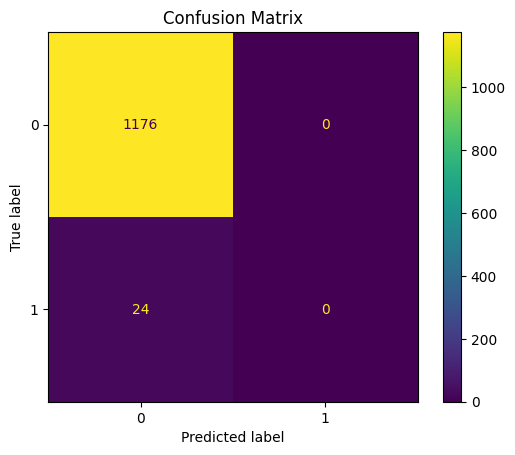

In [10]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()



# 12. Final Conclusion

## What Was Wrong?
The original notebook suffered from severe data leakage because one feature directly copied the target variable.

This caused unrealistically high accuracy.

---

## What Was Improved?
- Removed leakage feature
- Added stratified train-test split
- Added proper evaluation metrics
- Added confusion matrix
- Evaluated the model more realistically

---

## Key Learning
Very high accuracy does not always mean a model is good.

A machine learning pipeline must be carefully checked for:
- Data leakage
- Imbalanced classes
- Incorrect evaluation methods

Correct evaluation is more important than achieving extremely high scores.
